# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [14]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [15]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
print(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features
   Channel  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2  12669  9656     7561     214              2674        1338
1        2   7057  9810     9568    1762              3293        1776
2        2   6353  8808     7684    2405              3516        7844
3        1  13265  1196     4221    6404               507        1788
4        2  22615  5410     7198    3915              1777        5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [16]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
print(X_raw.describe().T)
print("\nMissing values: ", len(missing))
print("\nDuplicated values: ", X_raw.duplicated().sum())


                  count      mean       std   min      25%      50%       75%  \
Fresh            440.00 12,000.30 12,647.33  3.00 3,127.75 8,504.00 16,933.75   
Milk             440.00  5,796.27  7,380.38 55.00 1,533.00 3,627.00  7,190.25   
Grocery          440.00  7,951.28  9,503.16  3.00 2,153.00 4,755.50 10,655.75   
Frozen           440.00  3,071.93  4,854.67 25.00   742.25 1,526.00  3,554.25   
Detergents_Paper 440.00  2,881.49  4,767.85  3.00   256.75   816.50  3,922.00   
Delicassen       440.00  1,524.87  2,820.11  3.00   408.25   965.50  1,820.25   

                        max  
Fresh            112,151.00  
Milk              73,498.00  
Grocery           92,780.00  
Frozen            60,869.00  
Detergents_Paper  40,827.00  
Delicassen        47,943.00  

Missing values:  0

Duplicated values:  0


- Một dòng dữ liệu đại diện cho một khách hàng và 6 cột đại diện cho 6 nhóm chi tiêu hằng năm của khách hàng đó.

- Không có cột nào bị thiếu, trùng lặp hay sai kiểu dữ liệu, đáng lưu ý giá trị của Fresh đang khá cao so với các cột còn lại, có thể ảnh hưởng đến việc Training sau này.

- Channel/ Region nên được dùng trong giai đoạn Validation/Test, không nên dùng trong input clustering ban đầu vì đây giống như nhãn (label) đã biết trước, việc này khiến data leakage khiến cho mô hình tự tin vào khả năng của mình (Overfitting) nhưng rất kém khi gặp dữ liệu mới 

- Với chỉ dữ liệu chi tiêu, "hữu ích" trong business context là có thể phân nhóm khách hàng, tối ưu hoá lợi nhuận những tập khách hàng có mức chi tiêu cao, khuyến khích những khách hàng chi tiêu ít với nhiều ưu đãi hơn. 

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

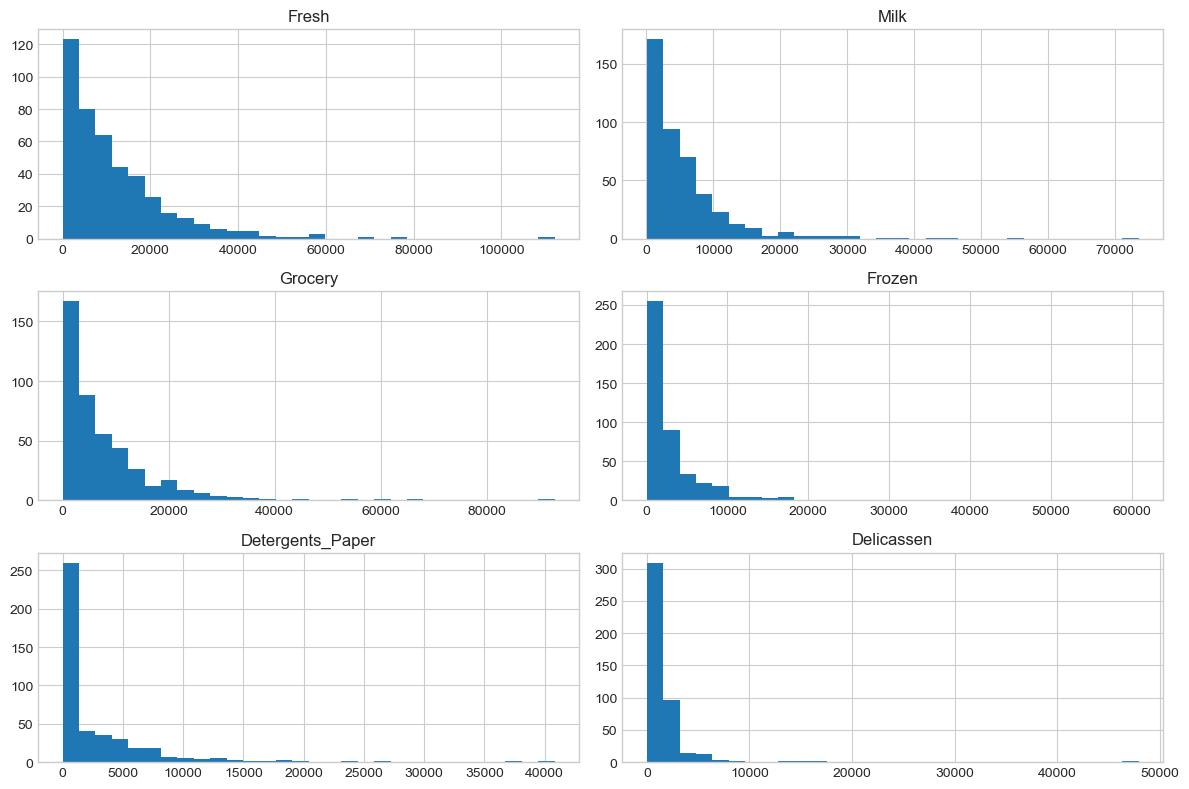

In [18]:
X_raw.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

Nhận xét:

- Tất cả nhóm chi tiêu đều lệch phải (right-skewed), cho thấy đa số khách hàng đều là tập chi tiêu ít.

- Feature `Fresh`có mức biến thiên đáng kể khi có outlier quá lớn, dẫn đến mean bị kéo lệch khá xa

> Vì có những dữ liệu rất xa so với đa số, ta có thể dùng log1p transform để nén dữ liệu 

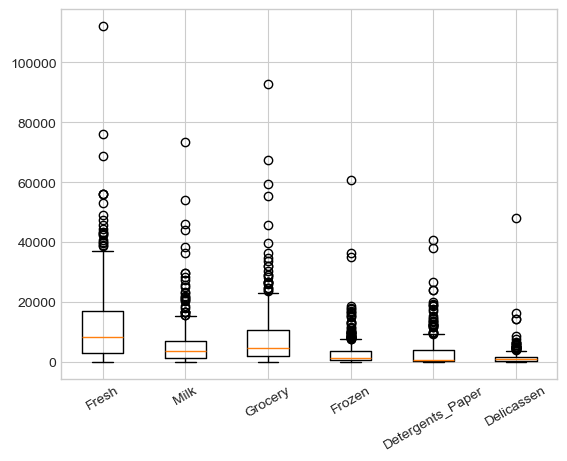

In [17]:
plt.boxplot(X_raw, tick_labels=SPENDING_FEATURES)
plt.xticks(rotation=30)
plt.show()

Nhận xét:

- Tuy lệch phải, Boxplot cho thấy số outliers cũng rất nhiều, vẫn tồn tại một số lượng khách hàng chi tiêu lớn cho các nhóm này 
> Không nên loại bỏ cái outliers này vì nó đại diện cho lượng khách hàng chi tiêu lớn chứ không phải sai sót trong quá trình thu thập dữ liệu. Tuy nhiên các dữ liệu đang có thang đo độ dài khác nhau, nên sử dụng `RobustScaler` để hạn chế độ nhạy với outliers.

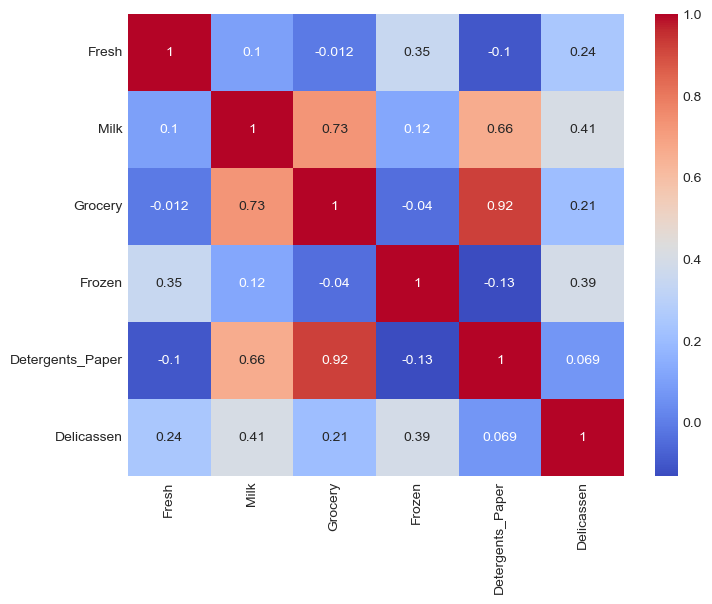

In [19]:
import seaborn as sns

corr = X_raw.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Nhận xét:
- `Grocery` và `Detergent_Paper` có mối tương quan dương mạnh (0.92), giữa `Milk` và `Detergent_Paper` cũng tương quan dương mạnh (0.66), và `Milk` với `Grocery` (0.73). Cả ba nhóm chi tiêu này có tương quan mật thiết đôi một với nhau

> Có thể cân nhắc PCA giảm chiều dữ liệu, hoặc Feature Selection bỏ bớt Features

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [20]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
X_model_robust = RobustScaler().fit_transform(np.log1p(X_raw))
X_model_std = StandardScaler().fit_transform(np.log1p(X_raw))


- `RobustScaler` để Scale lại các giá trị trong DataFrame và tránh việc nhạy với outliers vì outliers rất nhiều, (xử lý outliers và scale), tuy nhiên cũng có thể thử `StandardScaler`

- `Log1p` để nén dữ liệu (xử lý skew)

- Chọn `X_raw`, bộ dữ liệu không có `Channel` để tránh trường hợp bị data-leakage, dẫn đến Overfitting cho mô hình

- Một trade-off của lựa chọn `RobustScaler` + `Log1p` có thể là việc `Log1p` sau khi transform đã đủ tốt và `RobustScaler` xuất hiện không làm ảnh hưởng gì.

- Một trade-off của lựa chọn `StandardScaler` + `Log1p` có thể là việc `StandardScaler` có thể bị nhạy với outliers, dễ bị biased về một feature (`Fresh`)

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [21]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
model_rb_k = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_rb_k = model_rb_k.fit_predict(X_model_robust)
print("\n RobustScaler() with KMeans Classification")
print("Number of clusters:", len(np.unique(labels_rb_k)))
print(pd.Series(labels_rb_k).value_counts().sort_index())


model_rb_db = DBSCAN(eps=0.75,min_samples=5)
labels_rb_db = model_rb_db.fit_predict(X_model_robust)
unique_clusters_rb = set(labels_rb_db)
unique_clusters_rb.discard(-1)
n_clusters_rb = len(unique_clusters_rb)
print("\n RobustScaler() with DBSCAN Classification")
print("Number of clusters:", n_clusters_rb)
print("Noise:", (labels_rb_db == -1).sum())
print(pd.Series(labels_rb_db).value_counts().sort_index()[1:])


 RobustScaler() with KMeans Classification
Number of clusters: 3
0    209
1    149
2     82
Name: count, dtype: int64

 RobustScaler() with DBSCAN Classification
Number of clusters: 3
Noise: 136
0    284
1     12
2      8
Name: count, dtype: int64


In [22]:
model_std_k = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_std_k = model_std_k.fit_predict(X_model_std)
print("\n StandardScaler() with KMeans Classification")
print("Number of clusters:", len(np.unique(labels_std_k)))
print(pd.Series(labels_std_k).value_counts().sort_index())


model_std_db = DBSCAN(eps=0.75,min_samples=5)
labels_std_db = model_std_db.fit_predict(X_model_std)
unique_clusters_std = set(labels_std_db)
unique_clusters_std.discard(-1)
n_clusters_std = len(unique_clusters_std)
print("\n StandardScaler() with DBSCAN Classification")
print("Number of clusters:", n_clusters_std)
print("Noise:", (labels_std_db == -1).sum())
print(pd.Series(labels_std_db).value_counts().sort_index()[1:])


 StandardScaler() with KMeans Classification
Number of clusters: 3
0     80
1    147
2    213
Name: count, dtype: int64

 StandardScaler() with DBSCAN Classification
Number of clusters: 4
Noise: 281
0    141
1      5
2      5
3      8
Name: count, dtype: int64


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [23]:
sil = silhouette_score(X_model_std, labels_std_k)
db = davies_bouldin_score(X_model_std, labels_std_k)
def eval(name, model, label):
    if name == "RB_K":
        print("\nRobustScaler() with KMeans")
    elif name == "RB_DB":
        print("\nRobustScaler() with DBSCAN")
    elif name == "STD_K":
        print("\nStandardScaler() with KMeans")
    elif name == "STD_DB":
        print("\nStandardScaler() with DBSCAN")
    sil = silhouette_score(model, label)
    db = davies_bouldin_score(model, label)
    unique_clusters = set(label)
    unique_clusters.discard(-1)
    n_clusters = len(unique_clusters)
    noise_rate = (label == -1).mean()

    print(f"Noise rate: {noise_rate:.2%}")
    print("Silhouette:", sil)
    print("Davies-Bouldin:", db)
    print("Clusters:",n_clusters)
    print("\n")

eval("RB_K",X_model_robust, labels_rb_k)
eval("RB_DB",X_model_robust, labels_rb_db)
eval("STD_K",X_model_std, labels_std_k)
eval("STD_DB",X_model_std, labels_std_db)



RobustScaler() with KMeans
Noise rate: 0.00%
Silhouette: 0.24364659337885566
Davies-Bouldin: 1.3210599766071012
Clusters: 3



RobustScaler() with DBSCAN
Noise rate: 30.91%
Silhouette: 0.08928021139944675
Davies-Bouldin: 3.0797544152152367
Clusters: 3



StandardScaler() with KMeans
Noise rate: 0.00%
Silhouette: 0.2594156555974146
Davies-Bouldin: 1.3405631342807727
Clusters: 3



StandardScaler() with DBSCAN
Noise rate: 63.86%
Silhouette: -0.2599220213745852
Davies-Bouldin: 2.901545481217245
Clusters: 4




In [24]:
def ari(model,seeds = [18, 36, 67 ,367]):
    base_labels = KMeans(
        n_clusters=3,
        n_init=10,
        random_state=seeds[0]
    ).fit_predict(model)

    for seed in seeds[1:]:
        labels = KMeans(
            n_clusters=3,
            n_init=10,
            random_state=seed
        ).fit_predict(model)

        ari = adjusted_rand_score(base_labels, labels)
        print("Seed",seed,": ARI =" ,ari)

print("ARI for RobustScaler() model")
ari(X_model_robust)
print("\nARI for StandardScaler() model")
ari(X_model_std)


ARI for RobustScaler() model
Seed 36 : ARI = 1.0
Seed 67 : ARI = 1.0
Seed 367 : ARI = 1.0

ARI for StandardScaler() model
Seed 36 : ARI = 0.9679040219796282
Seed 67 : ARI = 0.9615305100720876
Seed 367 : ARI = 0.9778659531209278


- Model cuối : StandardScaler() với KMeans Classification
- Tham số : `n_clusters=3`,`n_init=10`

- Silhouette: ~0.26, tốt hơn so với 3 mô hình còn lại.
- Davies-Bouldin: ~1.34, ngang với RobustScalers + KMeans.
- Clusters : 3, ARI tương đối ổn định (~1)
- Không có noise, tốt hơn so với DBSCAN (dù có thể không tìm ra bộ trọng số eps phù hợp với nó, nhưng đủ để không ưu tiên DBSCAN trong bài này)


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


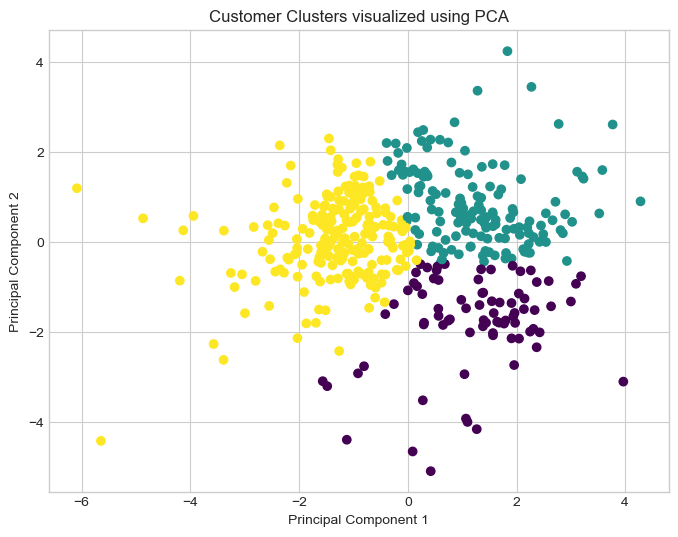

In [25]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model_std)

# X_pca = pca.fit_transform(X_model_std)

plt.figure(figsize=(8,6))

plt.scatter(
    coords[:,0],
    coords[:,1],
    c=labels_std_k,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters visualized using PCA")
plt.show()

- Mô hình sử dụng PCA để trực quan hoá sự phân cụm của các nhóm khách hàng trên không gian 2 chiều, hoàn toàn không dùng để đánh giá hay khẳng định chất lượng phân loại của mô hình vì từ 6 chiều xuống 2 chiều, nên sử dụng metrics để đánh giá chất lượng model.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [26]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
labels_final = labels_std_k
profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
print(profile)

            Fresh     Milk   Grocery   Frozen  Detergents_Paper  Delicassen
cluster                                                                    
0        1,492.50 6,300.50 10,502.50   376.00          4,217.50      434.50
1       12,126.00 7,184.00  9,965.00 2,005.00          3,378.00    2,005.00
2        9,612.00 1,601.00  2,155.00 2,121.00            274.00      686.00


**- Cluster 0 : "Grocery-Focused Customers"**

**Evidence** : Mặt hàng `Grocery` được nhóm khách hàng mua nhiều nhất (~10,500), sau đó đến `Milk`
(~6,300) và `Detergents_Paper`(~4,217), còn chi tiêu cho những mặt hàng như `Frozen`, `Fresh` và `Delicassen` đều có median thấp.

**Action Hypothesis**: Có thể thử triển khai các chương trình khuyến mãi cho những khách hàng này, đặc biệt là mặt hàng `Grocery` và `Detergents_Paper`, để kiểm tra liệu các khách hàng này có tăng tần suất mua hàng không.


**- Cluster 1 : "Broad and High-Value Customers"**

**Evidence** : Tất cả các mặt hàng đều được nhóm khách hàng này chi tiêu với median chi tiêu vượt trội, chỉ có chi tiêu cho `Grocery` và `Detergents_Paper` là thấp hơn so với nhóm khách hàng `Grocery-Focused`. Điều này cho thấy sự đa dạng và mạnh mẽ trong chi tiêu của nhóm khách hàng trên

**Action Hypothesis**: Có thể triển khai vouchers giảm giá, thẻ tri ân khách hàng có mức chi tiêu cao và đem lại lợi nhuận, khiến cho họ có thể sử dụng vouchers đó để tiếp tục chi tiêu

**- Cluster 2 : "Fresh-Focused Customers"**

**Evidence** : Mặt hàng `Fresh` được nhóm khách hàng này mua nhiều nhất (~9,612), còn chi tiêu cho những mặt hàng như `Detergents_Paper`, `Milk`, `Grocery` và `Delicassen` đều có median thấp.

**Action Hypothesis**: Vì những khách hàng có nhu cầu chi tiêu đối với các mặt hàng còn lại rất thấp, ta có thể thử chương trình khuyến mãi các danh mục chi tiêu trên để kiểm tra liệu khách hàng trong cụm này có sẵn sàng mở rộng danh mục mua sắm hay không


> **Dữ liệu còn thiếu** trước khi triển khai các chiến lược trên là lợi nhuận, tần suất, thời gian, phản hồi campaign. Việc bổ sung những thông tin trên đóng vai trò quyết định cho hướng đi của chiến dịch sau này. 

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [x] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [x] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [x] Có ≥2 thuật toán và quyết định model có evidence.
- [x] Có kiểm tra stability/robustness và diễn giải kết quả.
- [x] Không đọc PCA 2D như bằng chứng duy nhất.
- [x] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [x] Có giới hạn và kết luận business rõ ràng.


>Executive Summary:

1. Segmentation nên được triển khai ở quy mô thử nghiệm thay vì áp dụng ngay trên toàn bộ khách hàng, do còn thiếu dữ liệu về lợi nhuận, tần suất mua hàng, lịch sử mua hàng theo thời gian và phản hồi từ các chiến dịch trước đây. Khi có những thông tin trên, việc đánh giá hiệu quả chiến dịch sẽ có cơ sở và thuyết phục trong thực tế. 

2. Model được chọn là KMeans trên dữ liệu đã được tiền xử lý bằng log1p và StandardScaler vì có Silhouette tốt nhất, Davies-Bouldin ổn và duy trì được sự ổn định khi thay đổi random_state (ARI > 0.96). 

3. Những khám phá quan trọng nhất sau quá trình khai phá dữ liệu : quá trình phân tích cho thấy tồn tại một nhóm khách hàng có mức chi tiêu mạnh mẽ và rộng khắp các danh mục. Tiếp đến là 2 ngách khách hàng nhỏ, tập trung vào chi tiêu thực phẩm danh mục Fresh, và nhóm khách hàng tập trung vào chi tiêu cho sản phẩm Grocery. 

4. Do vậy, có thể thử trước các chương trình khuyến mãi nhắm mục tiêu đến hai nhóm khách hàng chuyên biệt và đánh giá hiệu quả thông qua tần suất mua hàng, giá trị đơn hàng và tỷ lệ phản hồi của chiến dịch.

5. Phân tích hiện chỉ dựa trên dữ liệu chi tiêu theo danh mục sản phẩm. Việc thiếu dữ liệu về lợi nhuận, tần suất mua hàng, lịch sử mua hàng theo thời gian và phản hồi từ các chiến dịch marketing khiến các đề xuất hiện tại mới dừng ở mức giả thuyết và cần được kiểm chứng trước khi triển khai trên quy mô lớn.